In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from numpy import double, int_
from numpy.typing import NDArray
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from sympy import Piecewise, integrate, symbols
from tqdm import tqdm

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR
    / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR
    / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered.nc"
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

In [3]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)
bathymetry = xr.open_mfdataset(GEBCO_PATH)

# interpolate velocity depths to match 1 meter bins in midshelf nitrate
velocity = velocity.interp(depth=midshelf_nitrate.depth)

In [4]:
def dt2cal(dt):
    """
    Convert array of datetime64 to a calendar array of year, month, day, hour,
    minute, seconds, microsecond with these quantites indexed on the last axis.

    Args:
        dt (array of datetime64): datetimes to convert

    Returns:
        array: calendar array with last axis representing year, month, day, hour,
            minute, second, microsecond
    """
    # allocate output
    out = np.empty(dt.shape + (7,), dtype="u4")
    # decompose calendar floors
    Y, M, D, h, m, s = [dt.astype(f"M8[{x}]") for x in "YMDhms"]
    out[..., 0] = Y + 1970  # Gregorian Year
    out[..., 1] = (M - Y) + 1  # month
    out[..., 2] = (D - M) + 1  # date
    out[..., 3] = (dt - D).astype("m8[h]")  # hour
    out[..., 4] = (dt - h).astype("m8[m]")  # minute
    out[..., 5] = (dt - m).astype("m8[s]")  # second
    out[..., 6] = (dt - s).astype("m8[us]")  # microsecond
    return out


def find_nearest(
    array: NDArray[double | int_], value: double | int_ | float | int
) -> int | None:
    if np.all(np.isnan(array)):
        return None
    array = np.asarray(array)
    idx = int(np.nanargmin((np.abs(array - value))))
    return idx


def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)

    Args:
        lon1 (scalar): longitude of first point
        lat1 (scalar): latitude of first point
        lon2 (scalar): longitude of second point
        lat2 (scalar): latitude of second point

    Returns:
        scalar: distance in km between (lon1, lat1) and (lon2, lat2)
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km


def pycno(x, zf, r, h=125):
    """
    Function for an idealized representation of the 25.8 kg/m^3 isopycnal.
    See Austin and Barth, 2002

    Args:
        x (scalar or array): cross-shelf distance in km
        zf (scalar): z intercept of the 25.8 kg/m^3 isopycnal in m
        r (scalar): radius of deformation in km
        h (int, optional): Offshore decay depth of the pycnocline. Defaults to 125.

    Returns:
        scalar or array: cross-shelf depth of the 25.8 kg/m^3 isopycnal
    """
    return -h + (zf + h) * np.exp(x / r)


def ws_integrand(tp, t, tau, k, rho=1000):
    """
    Integrand for computation of 8-day exponentially weighted integral of
    wind stress. See Austin and Barth, 2002.

    Args:
        tp (array): integration variable, time
        t (scalar): upper limit of integration, time
        tau (array): wind stress array with same lenth as times tp
        k (scalar): relaxation timescale, same units as time
        rho (scalar, optional): Density of sea water. Defaults to 1000.

    Returns:
        array: integrand for use in scipy.integrate and computation of W8d
    """
    return tau[: t + 1] / rho * np.exp((tp[: t + 1] - t) / k)

## 2 Layer Model Computation

Computes the simple model for nearshore nitrate based on a piecewise function utilizing the Sympy library and then integrates over the depth to get a mean depth averaged nitrate predicted by the model.

In [5]:
bathymetry = bathymetry.isel(dict(lat=find_nearest(bathymetry["lat"].values, 44.66)))
bathymetry = bathymetry.interp(dict(lon=np.linspace(-130, -123, int(1e6))))
topo = bathymetry["elevation"].squeeze().values
coast = bathymetry.isel(dict(lon=np.argmin(np.abs(topo))))


bathymetry = bathymetry.interp(dict(lon=np.linspace(-130, -123, int(1e4))))
topo = bathymetry["elevation"].squeeze().values
long = bathymetry.lon.values
lat = bathymetry.lat.values

meters = np.nan * np.zeros(len(long))
for i, lo in enumerate(long):
    meters[i] = haversine(long[0], lat, long[i], lat) - haversine(
        long[0], lat, coast.lon.values, lat
    )

long = long[meters > -100]
topo = topo[meters > -100]
meters = meters[meters > -100]

delta = 0.01  # nitracline width in meters
step = 0.1
r = 43
h = 125
Nm = 35
zf = np.arange(-100, 100, 0.5)
x0 = 3  # meters[np.argmin(np.abs(long + 124.095))]
bot_depth = topo[np.argmin(np.abs(long + 124.095))]

mod_nit = np.nan * np.zeros((len(inner_nitrate.depth.values), len(zf)))
mod_nda = np.nan * np.zeros(len(zf))

z = symbols("z")
for i in tqdm(range(len(zf))):
    dn = pycno(x0, zf[i], r, h)
    n_profile = Piecewise(
        (0, z > dn),
        (Nm, z < dn),
    )
    mod_nit[:, i] = [n_profile.subs(z, val) for val in -inner_nitrate.depth.values]
    mod_nda[i] = integrate(n_profile, (z, bot_depth, 0)) / np.abs(bot_depth)

100%|██████████| 400/400 [00:04<00:00, 90.64it/s] 


## NHL Fits

Determines the depth of the 25.8 $\sigma_\theta$ isopycnal as a function of cross-shelf distance for the gridded NHL data. Then fits NHL cross-shelf 25.8 $\sigma_\theta$ transects with a best fit exponential of the form $H - (Z_f-H)exp(-x/R_0)$. Also discards fits with unreasonably large R, H, or Zf.

In [6]:
# load NHL transects and compute distance from coastline in meters
nhl_grid = xr.load_dataset(
    "../../datasets/ship/Newport_Hydrographic_Line_Data_1997_2021/data_files/newport_hydrographic_line_gridded_sections.nc"
)
nhl_grid = nhl_grid.squeeze()
nhl_grid = nhl_grid.where(nhl_grid.pressure > 10)
nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"], nhl_grid["latitude"], -124.0590, nhl_grid["latitude"]
)
print(f"Total number of NHL transects: {len(nhl_grid.time)}")
nhl_grid = nhl_grid.where(
    ((nhl_grid["time.month"] > 3) & (nhl_grid["time.month"] < 11)), drop=True
)
print(f"Total number of summertime NHL transects: {len(nhl_grid.time)}")
# linearly interpolate to find 25.8 isopycnal depth
pycno_depth = np.nan * np.zeros((len(nhl_grid["meters"]), len(nhl_grid["time"])))
for i, x in enumerate(tqdm(nhl_grid["meters"])):
    for j, t in enumerate(nhl_grid["time"]):
        mask = ~np.isnan(nhl_grid["potential_density"][i, :, j])
        temp = nhl_grid["potential_density"][i, :, j][mask]
        if len(temp > 0):
            try:
                pycno_depth[i][j] = np.interp(
                    25.8,
                    nhl_grid["potential_density"][i, :, j][mask],
                    nhl_grid["pressure"][mask],
                )
                # pycno_depth[i][j] = inter
            except ValueError:
                pycno_depth[i][j] = np.nan
                pass
nhl_grid["pycno_depth"] = (["longitude", "time"], -pycno_depth)
# nhl_grid = nhl_grid.where(nhl_grid.pycno_depth < -10)

# free H code
R = np.nan * np.zeros(len(pycno_depth.T))
R_err = np.nan * np.zeros(len(pycno_depth.T))
Zf = np.nan * np.zeros(len(pycno_depth.T))
Zf_err = np.nan * np.zeros(len(pycno_depth.T))
H = np.nan * np.zeros(len(pycno_depth.T))
H_err = np.nan * np.zeros(len(pycno_depth.T))

nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"], nhl_grid["latitude"], -124.0590, nhl_grid["latitude"]
)

for i, d in enumerate(tqdm(-pycno_depth.T)):
    mask = ~np.isnan(d)
    if len(d[mask]) > 20:
        (Zf[i], R[i], H[i]), cov = curve_fit(
            pycno, nhl_grid["meters"][mask], d[mask], p0=[0, 50, 125]
        )  # , bounds=([-np.inf, 0, 0], [np.inf, 1000, 2000])
        (Zf_err[i], R_err[i], H_err[i]) = np.sqrt(np.diagonal(cov))

nhl_grid["R"] = (["time"], R)
nhl_grid["Zf"] = (["time"], Zf)
nhl_grid["H"] = (["time"], H)
nhl_grid["Zf_err"] = (["time"], Zf_err)

nhl_grid = nhl_grid.resample(time="1D").median()
nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"], nhl_grid["latitude"], -124.0590, nhl_grid["latitude"]
)

mask = (~np.isnan(nhl_grid.H)) & (~np.isnan(nhl_grid.R)) & (~np.isnan(nhl_grid.Zf))
mask = xr.DataArray(mask, dims=["time"], coords=dict(time=nhl_grid.time.values))
nhl_grid = nhl_grid.where(mask, drop=True)
print(f"Total number of reasonable fits: {len(nhl_grid.time)}")

nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"], nhl_grid["latitude"], -124.0590, nhl_grid["latitude"]
)

fit_rmse = np.nan * np.empty(len(nhl_grid.time))
for i, t in enumerate(nhl_grid.time):
    temp = nhl_grid.sel(time=t)
    residuals = temp.pycno_depth - pycno(
        temp.meters.values, temp.Zf.values, temp.R.values, temp.H.values
    )
    fit_rmse[i] = ((np.sum(residuals**2) / (residuals.size - 2)) ** 0.5).values

mask = (~np.isnan(nhl_grid.H)) & (~np.isnan(nhl_grid.R)) & (~np.isnan(nhl_grid.Zf))
mask = xr.DataArray(mask, dims=["time"], coords=dict(time=nhl_grid.time.values))
nhl_grid = nhl_grid.where(mask, drop=True)
print(f"Total number of reasonable fits: {len(nhl_grid.time)}")

# # for removing fits with huge R, H
# mask = ((~np.isnan(nhl_grid.H)) & (~np.isnan(nhl_grid.R)) & (~np.isnan(nhl_grid.Zf)))
# mask = xr.DataArray(mask, dims=['time'], coords=dict(time=nhl_grid.time.values))
# nhl_grid = nhl_grid.where(mask, drop=True)
# print(f'Total number of reasonable fits: {len(nhl_grid.time)}')

fit_rmse = np.nan * np.empty(len(nhl_grid.time))
for i, t in enumerate(nhl_grid.time):
    temp = nhl_grid.sel(time=t)
    residuals = temp.pycno_depth - pycno(
        temp.meters.values, temp.Zf.values, temp.R.values, temp.H.values
    )
    fit_rmse[i] = ((np.sum(residuals**2) / (residuals.size - 2)) ** 0.5).values

Total number of NHL transects: 556
Total number of summertime NHL transects: 396


 24%|██▍       | 97/396 [00:02<00:06, 44.21it/s]C:\Users\asche\AppData\Local\Temp\ipykernel_28876\3401808334.py:50: OptimizeWarning: Covariance of the parameters could not be estimated
  (Zf[i], R[i], H[i]), cov = curve_fit(
100%|██████████| 396/396 [00:07<00:00, 53.13it/s]


Total number of reasonable fits: 344
Total number of reasonable fits: 344


100%|██████████| 5/5 [00:08<00:00,  1.79s/it]


158

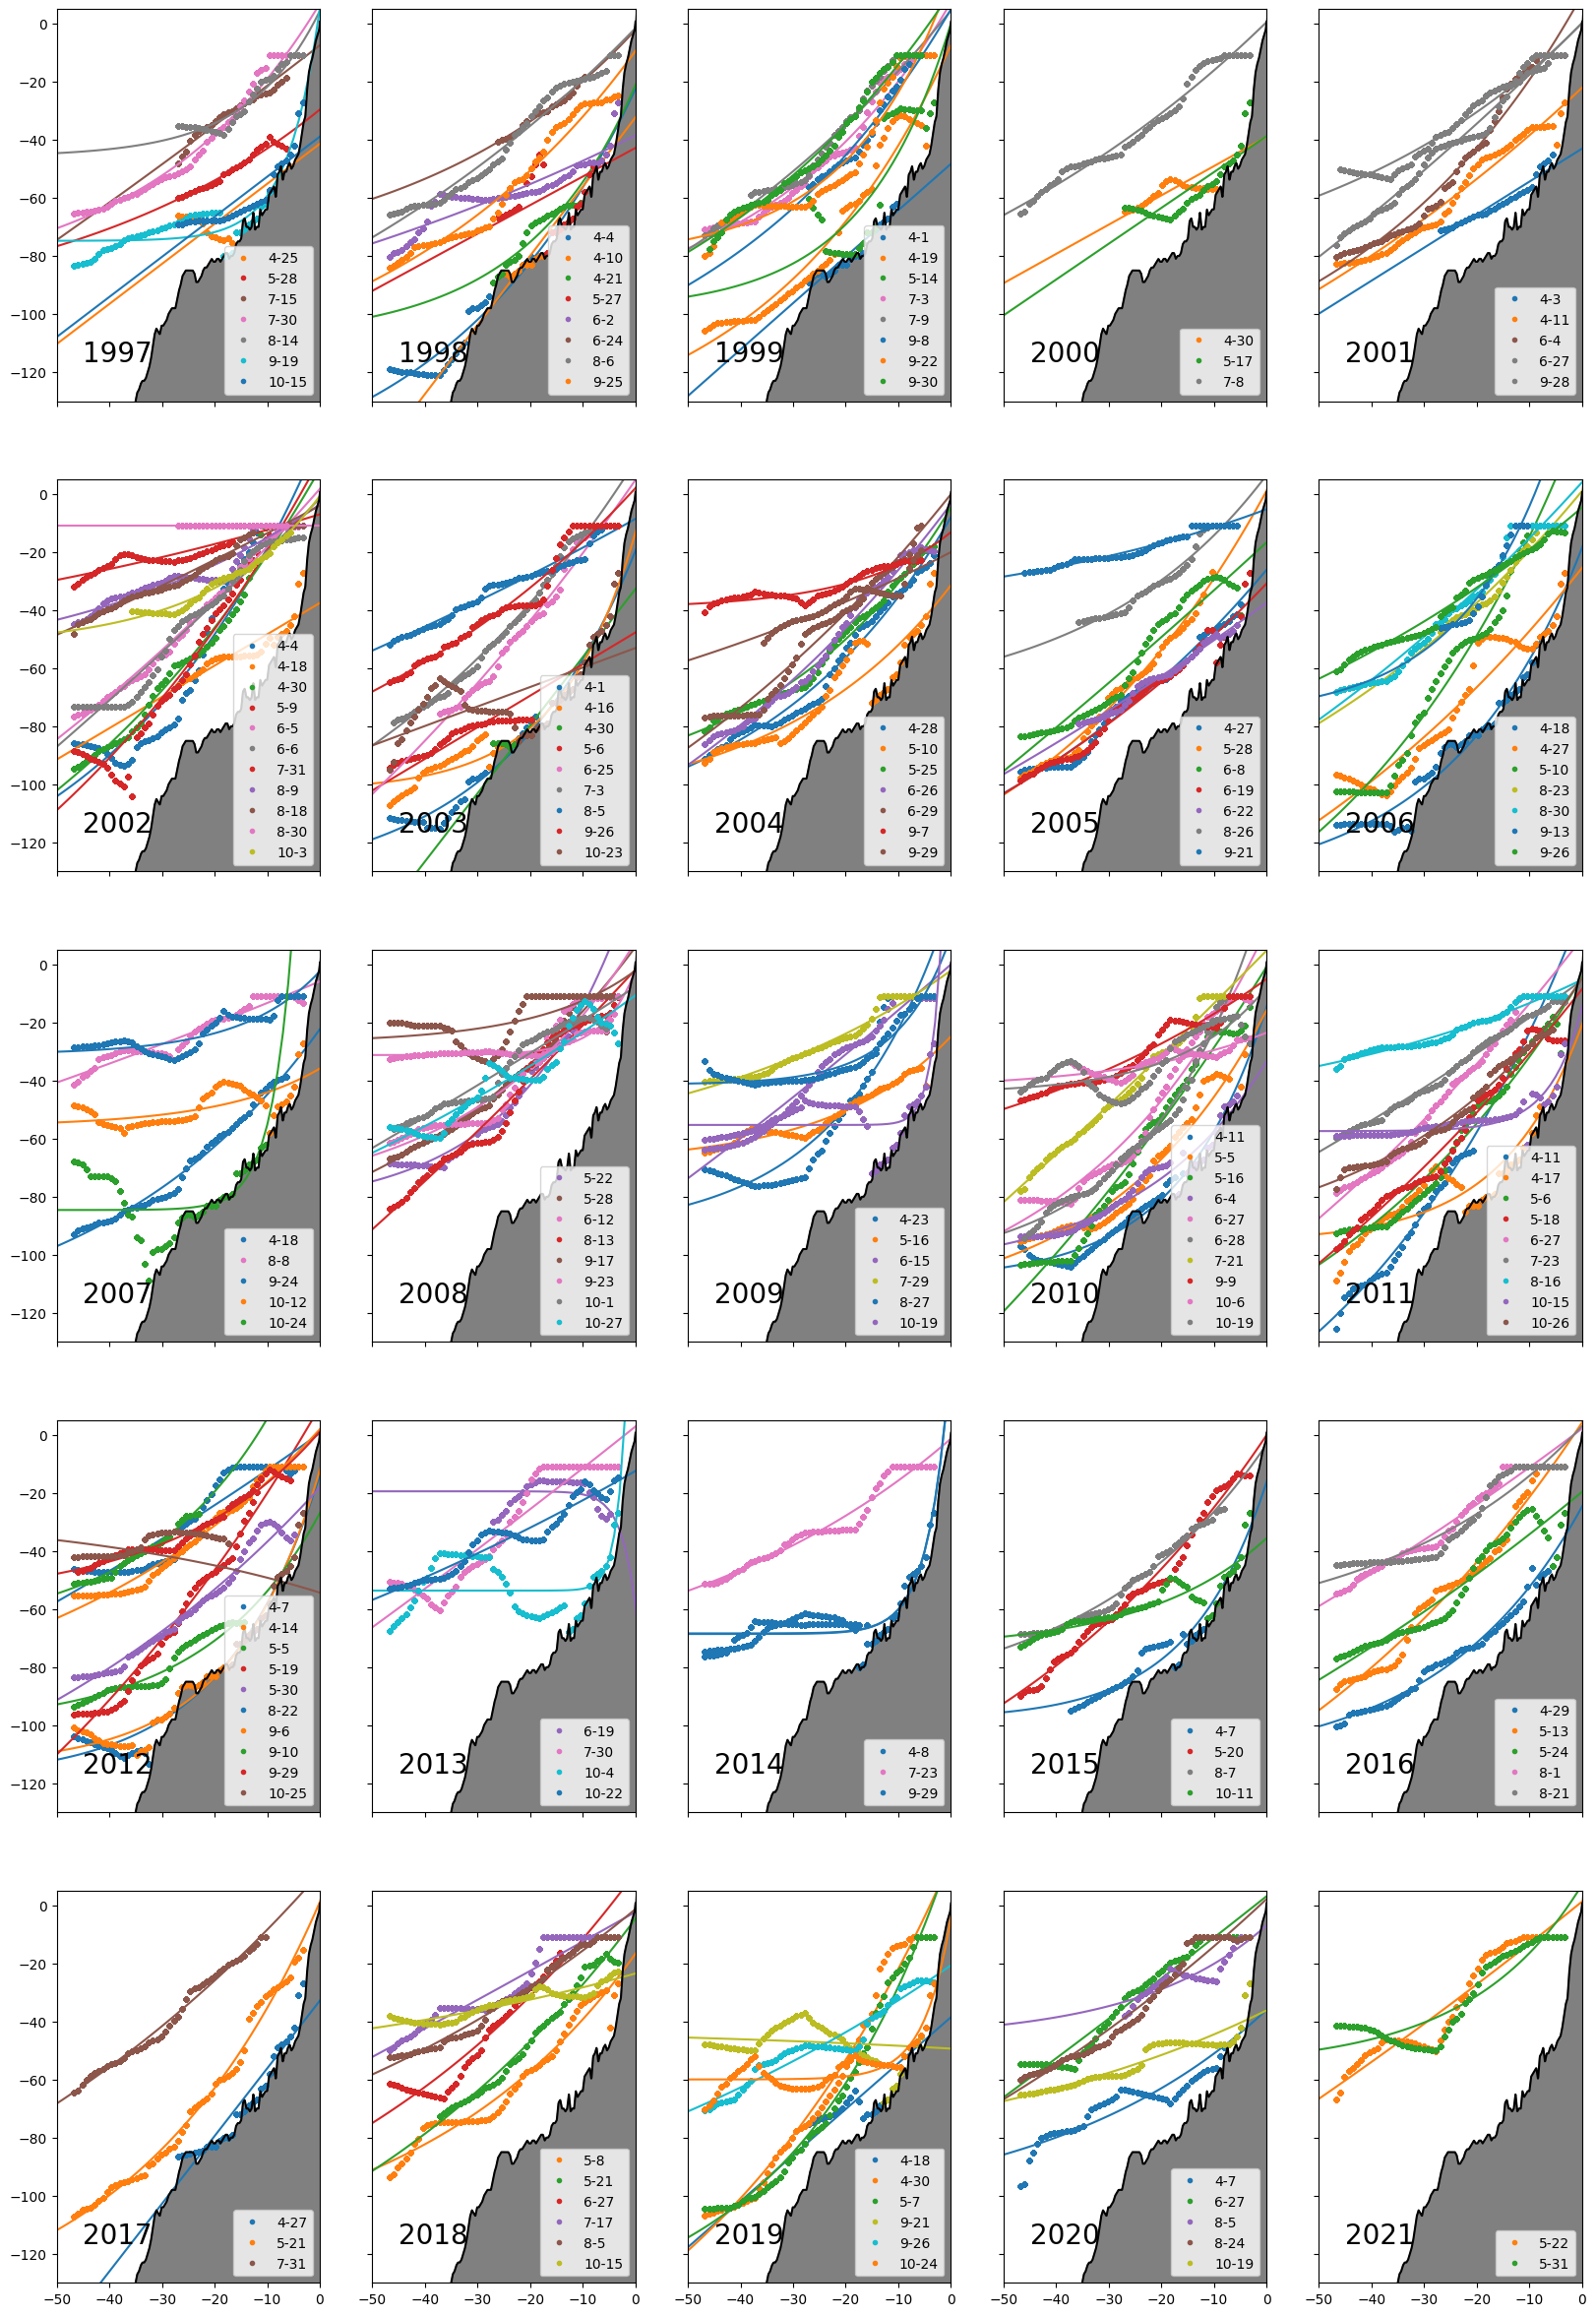

In [7]:
# plot transects and fits
col = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]
trange = np.arange(
    np.datetime64("1997"),
    np.datetime64("2022"),
    np.timedelta64(1, "Y"),
    dtype="datetime64[Y]",
)
tdelta = np.timedelta64(1, "Y")
rows = 5
cols = 5
N = 0
fig, axs = plt.subplots(5, 5, figsize=(20, 30), sharex=True, sharey=True)
for r in tqdm(range(rows)):
    for c in range(cols):
        mask = (nhl_grid["time"] >= trange[5 * r + c % 5]) & (
            nhl_grid["time"] < trange[5 * r + c % 5] + tdelta
        )
        for i, (t, d, Zf, R, H) in enumerate(
            zip(
                nhl_grid["time"][mask].values,
                nhl_grid["pycno_depth"][mask].values,
                nhl_grid["Zf"][mask].values,
                nhl_grid["R"][mask].values,
                nhl_grid["H"][mask].values,
            )
        ):
            mask = ~np.isnan(d) & (nhl_grid.meters.T[0] < -10)
            ymd = dt2cal(t)[0:3]
            if len(d[mask]) > 15:
                if R < 999:
                    axs[r][c].plot(
                        nhl_grid["meters"],
                        d,
                        ".",
                        label=f"{ymd[1]}-{ymd[2]}",
                        c=col[i % len(col)],
                    )
                    axs[r][c].plot(
                        np.arange(-50, 5),
                        pycno(np.arange(-50, 5), Zf, R, H),
                        c=col[i % len(col)],
                    )
                    N += 1
        axs[r][c].annotate(ymd[0], xy=(0.1, 0.1), xycoords="axes fraction", fontsize=20)
        axs[r][c].fill_between(meters, -1000, topo, color="grey")
        axs[r][c].plot(meters, topo, color="black")
        handles, labels = axs[r][c].get_legend_handles_labels()
        by_label = dict(
            zip(labels, handles)
        )  # dicts can't have duplicate keys, avoids duplicate legend entries
        axs[r][c].legend(by_label.values(), by_label.keys(), loc="lower right")
        axs[r][c].set_ylim([-130, 5])
        axs[r][c].set_xlim([-50, 0])
N

## Zf, R, H Time Series

R median: 36.19
H median: 105.19


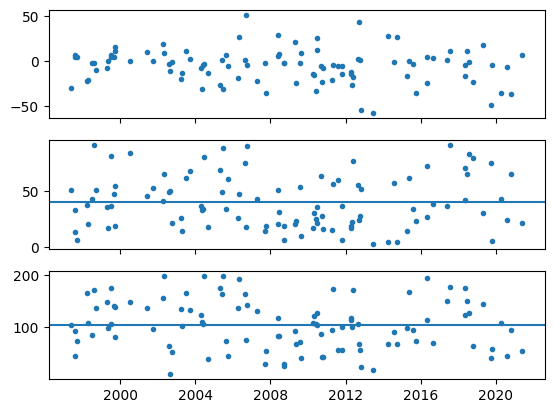

In [8]:
fig, axs = plt.subplots(3, 1, sharex=True)
mask = (
    (nhl_grid.Zf < 100)
    & (nhl_grid.Zf > -100)
    & (nhl_grid.R < 100)
    & (nhl_grid.R > -100)
    & (nhl_grid.H < 200)
)
axs[0].plot(nhl_grid.time[mask], nhl_grid.Zf[mask], ".")
# axs[0].plot(nhl_grid.time, nhl_grid.Zf, '.')
# axs[0].set_ylim(-75, 125)
axs[1].plot(nhl_grid.time[mask], nhl_grid.R[mask], ".")
# axs[1].plot(nhl_grid.time, nhl_grid.R, '.')
# axs[1].set_ylim(-10, 200)
# axs[1].set_yscale('log')
axs[1].axhline(np.nanmean(nhl_grid.R[mask]))
# axs[1].axhline(np.nanmedian(nhl_grid.R))
axs[2].plot(nhl_grid.time[mask], nhl_grid.H[mask], ".")
# axs[2].plot(nhl_grid.time, nhl_grid.H, '.')
# axs[2].set_ylim(1, 2100)
# axs[2].set_yscale('log')
axs[2].axhline(np.nanmedian(nhl_grid.H[mask]))
# axs[2].axhline(np.nanmedian(nhl_grid.H))
print(f"R median: {np.nanmedian(nhl_grid.R[mask]):.2f}")
# print(f'R mean: {np.nanmedian(nhl_grid.R):.2f}')
print(f"H median: {np.nanmedian(nhl_grid.H[mask]):.2f}")
# print(f'H mean: {np.nanmedian(nhl_grid.H):.2f}')

## 25.8 Fit

Text(0.07, 0.63, '25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data')

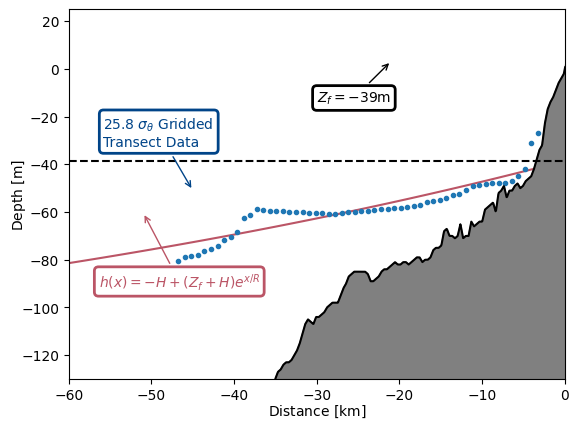

In [9]:
fig, axs = plt.subplots()
d = nhl_grid.isel(time=15)
mask = ~np.isnan(d)
axs.plot(d["meters"], d["pycno_depth"], ".")
axs.plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs.fill_between(meters, -1000, topo, color="grey")
axs.plot(meters, topo, color="black")
axs.set_ylim([-130, 25])
axs.set_xlim([-60, 0])
axs.set_xlabel("Distance [$\\mathsf{km}$]", labelpad=0)
axs.set_ylabel("Depth [$\\mathsf{m}$]", labelpad=-5)
bbox = dict(boxstyle="round", fc="w", ec="#BB5566", lw=2)
axs.annotate(
    "$h(x)=-H+(Z_f+H)e^{x/R}$",
    xy=(0.15, 0.45),
    xytext=(0.06, 0.25),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="#BB5566"),
    color="#BB5566",
)
axs.axhline(d.Zf, ls="--", color="k")
bbox = dict(boxstyle="round", fc="w", ec="k", lw=2)
axs.annotate(
    f"$Z_f={d.Zf.values:.0f} \\mathsf{{m}}$",
    xy=(0.65, 0.86),
    xytext=(0.5, 0.75),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="k"),
    color="k",
)
bbox = dict(boxstyle="round", fc="w", ec="#004488", lw=2)
axs.annotate(
    "25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data",
    xy=(0.25, 0.51),
    xytext=(0.07, 0.63),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="#004488"),
    color="#004488",
)
# if savefigs:
#     plt.savefig("../../figs/pycno_fit.png", dpi=600)

## Zf-Wind Fit

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.477
Model:                            WLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     250.8
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           1.37e-40
Time:                        20:18:08   Log-Likelihood:                -1096.5
No. Observations:                 277   AIC:                             2197.
Df Residuals:                     275   BIC:                             2204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.5490      0.656    -23.713      0.000     -16.840     -14.258
x1          -299.3678     18.903    -15.837      0.000    -336.582    -262.154
==============================================================================
Omnibus:                       68.739   Durbin-Watson:                   1.370
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              159.535
Skew:                          -1.185   Prob(JB):                     2.28e-35
Kurtosis:                       5.864   Cond. No.                         36.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

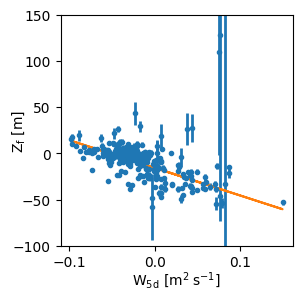

In [10]:
wind_use = "w5d"
wind_al_nhl, nhl_al_wind = xr.align(wind, nhl_grid)
m = dt2cal(nhl_al_wind["time"].values).T[1]
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use]))
wls_fit = sm.WLS(
    nhl_al_wind["Zf"][mask].values,
    sm.add_constant(wind_al_nhl[wind_use][mask].values),
    1 / (nhl_al_wind["Zf_err"][mask].values ** 2),
    missing="drop",
).fit()
fit = wls_fit.params[::-1]
r_squared = wls_fit.rsquared

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
ax.plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
ax.set_ylim(-100, 150)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{m^2 \\; s^{-1}}$]", labelpad=0)
ax.set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
bbox = dict(boxstyle="round", fc="w")
# ax.annotate(
#     f'$\\beta_0={fit[1]:.2f}$ $\\mathsf{{m}}$\n$\\beta_1={fit[0]:.2f}$ $\\mathsf{{s/m}}$\n${{R^2={r_squared:.2f}}}$',
#     xy=(0.95, 0.95),
#     xycoords='axes fraction',
#     bbox=bbox,
#     fontsize=10,
#     ha='right',
#     va='top'
# )
wls_fit.summary()

Text(0.85, 0.05, '(c)')

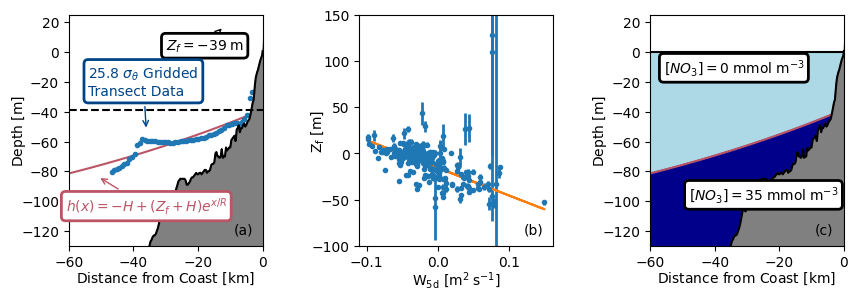

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
plt.subplots_adjust(wspace=0.5)

d = nhl_grid.isel(time=15)
mask = ~np.isnan(d)
axs[0].plot(d["meters"], d["pycno_depth"], ".")
axs[0].plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs[0].fill_between(meters, -1000, topo, color="grey")
axs[0].plot(meters, topo, color="black")
axs[0].set_ylim([-130, 25])
axs[0].set_xlim([-60, 0])
axs[0].set_xlabel("Distance from Coast [$\\mathsf{km}$]", labelpad=0)
axs[0].set_ylabel("Depth [$\\mathsf{m}$]", labelpad=-5)
axs[0].minorticks_off()
bbox = dict(boxstyle="round", fc="w", ec="#BB5566", lw=2)
axs[0].annotate(
    "$h(x)=-H+(Z_f+H)e^{x/R}$",
    xy=(0.15, 0.3),
    xytext=(0.4, 0.15),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="#BB5566"),
    color="#BB5566",
    ha="center",
)
axs[0].axhline(d.Zf, ls="--", color="k")
bbox = dict(boxstyle="round", fc="w", ec="k", lw=2)
axs[0].annotate(
    f"$Z_f={d.Zf.values:.0f} \\; \\mathsf{{m}}$",
    xy=(0.8, 0.95),
    xytext=(0.5, 0.85),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="k"),
    color="k",
)
bbox = dict(boxstyle="round", fc="w", ec="#004488", lw=2)
axs[0].annotate(
    "25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data",
    xy=(0.4, 0.5),
    xytext=(0.1, 0.65),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="#004488"),
    color="#004488",
)


# compare results below for rough estimates from AB 2002: a~=-0.85,b~=-23
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use]))
axs[1].errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
axs[1].plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
axs[1].set_ylim(-100, 150)
axs[1].set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{m^2 \\; s^{-1}}$]", labelpad=0)
axs[1].set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
axs[1].minorticks_off()
bbox = dict(boxstyle="round", fc="w")
# axs[1].annotate(f'$\\beta_0={fit[1]:.2f}$ $\\mathsf{{m}}$\n$\\beta_1={fit[0]:.2f}$ $\\mathsf{{s/m}}$\n${{R^2={r_squared:.2f}}}$', xy=(0.95, 0.95), xycoords='axes fraction', bbox=bbox, fontsize=10, ha='right', va='top')


d = nhl_grid.isel(time=15)
mask = ~np.isnan(d)
axs[2].fill_between(
    np.arange(-60, 5)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],
    0,
    color="lightblue",
)
axs[2].fill_between(
    np.arange(-60, 5)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],
    -1000,
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],
    color="darkblue",
)
axs[2].fill_between(
    np.arange(-60, 5)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) >= -1
    ],
    -1000,
    0,
    color="darkblue",
)
axs[2].plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs[2].fill_between(meters, -1000, topo, color="grey")
axs[2].plot(meters, topo, color="black")
axs[2].axhline(0, c="k")
axs[2].set_ylim([-130, 25])
axs[2].set_xlim([-60, 0])
axs[2].set_xlabel("Distance from Coast [$\\mathsf{km}$]", labelpad=0)
axs[2].set_ylabel("Depth [$\\mathsf{m}$]", labelpad=-5)
axs[2].minorticks_off()
bbox = dict(boxstyle="round", fc="w", ec="k", lw=2)
axs[2].annotate(
    "$[NO_3]=0 \\; \\mathsf{mmol \\; m^{-3}}$",
    xy=(0.07, 0.75),
    xytext=(0.07, 0.75),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="k"),
    color="k",
)
bbox = dict(boxstyle="round", fc="w", ec="k", lw=2)
axs[2].annotate(
    "$[NO_3]=35 \\; \\mathsf{mmol \\; m^{-3}}$",
    xy=(0.2, 0.2),
    xytext=(0.2, 0.2),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops=dict(arrowstyle="->", color="k"),
    color="k",
)


axs[0].annotate("(a)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)

# plt.savefig(os.path.join(notebook_dir, "../manuscript/simple_model.pdf"), format="pdf")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     1182.
Date:                Fri, 25 Apr 2025   Prob (F-statistic):          3.88e-161
Time:                        20:18:09   Log-Likelihood:                -2703.3
No. Observations:                 823   AIC:                             5411.
Df Residuals:                     821   BIC:                             5420.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8451      0.384     10.012      0.000       3.091       4.599
x1             0.6861      0.020     34.375      0.000       0.647       0.725
==============================================================================
Omnibus:                       17.638   Durbin-Watson:                   0.535
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.177
Skew:                           0.354   Prob(JB):                     0.000113
Kurtosis:                       3.167   Cond. No.                         32.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

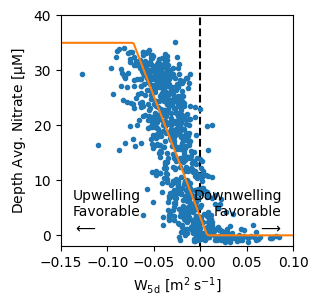

In [12]:
wind_al_nitrate, nitrate_al_wind = xr.align(wind, inner_nitrate)
# fit[1] = -400
slope = 1 / (fit[0])
intercept = -(-30) * slope

fig, ax = plt.subplots(figsize=(3, 3))
ax.axvline(0, ls="--", color="black")
ax.plot(
    wind_al_nitrate[wind_use],
    nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True),
    ".",
)
ax.set_xlim(-0.15, 0.1)
ax.set_ylim(-2, 40)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{m^2 \\; s^{-1}}$]")
ax.set_ylabel("Depth Avg. Nitrate $[\\mathsf{\\mu M}]$")
ax.plot(slope * zf + intercept, mod_nda)
ax.text(
    0.05,
    0.06,
    "Upwelling\nFavorable\n$\\longleftarrow$",
    transform=ax.transAxes,
    fontsize=10,
)
ax.text(
    0.95,
    0.06,
    "Downwelling\nFavorable\n$\\longrightarrow$",
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
)

# computing r^2 between fit and data
xp = slope * zf + intercept
xp_idx = xp.argsort()
xp = xp[xp_idx]
mod_nda_idx = mod_nda[xp_idx]
mod_nda_interp = np.interp(wind_al_nitrate[wind_use], xp, mod_nda_idx)
mask = ~np.isnan(mod_nda_interp) & ~np.isnan(
    nitrate_al_wind["nitrate"].median(dim="depth", skipna=True)
)
ols_fit = sm.OLS(
    mod_nda_interp[mask],
    sm.add_constant(
        (nitrate_al_wind["nitrate"].median(dim="depth", skipna=True)[mask]).values
    ),
).fit()
bbox = dict(boxstyle="round", fc="w")
# ax.annotate(f'${{R^2={ols_fit.rsquared:.2f}}}$', xy=(0.95, 0.95), xycoords='axes fraction', bbox=bbox, fontsize=10, ha='right', va='top')

# plt.savefig(
#     os.path.join(notebook_dir, "../manuscript/wind-nitrate.pdf"),
#     format="pdf",
#     bbox_inches="tight",
# )
ols_fit.summary()

In [13]:
tdelay = np.arange(1, 21)
wkd_correlation_zf = np.nan * np.zeros(tdelay.shape)
for i, t in enumerate(tqdm(tdelay)):
    fout = np.nan * np.zeros(len(wind["day_num"]))
    for j, f in enumerate(fout):
        temp = ws_integrand(
            wind["day_num"].values[j - t * 5 : j],
            wind["day_num"].values[j],
            wind["coare_y"].values[j - t * 5 : j],
            t,
            rho=1,
        )
        mask = ~np.isnan(temp)
        if not np.any(np.isnan(wind.coare_y[j - t * 5 : j])) and not temp.size == 0:
            fout[j] = (
                simpson(temp[mask], x=wind["day_num"].values[j - t * 5 : j][mask]) / t
            )
    temp = xr.Dataset(
        data_vars=dict(wkd=(["time"], fout)), coords=dict(time=wind["time"])
    )
    temp_wind, temp_nhl = xr.align(temp, nhl_grid)
    m = dt2cal(temp_nhl["time"].values).T[1]
    mask = (temp_nhl["Zf"] < 100) & (temp_nhl["Zf"] > -100)
    summer = (
        (m >= 4)
        & (m <= 9)
        & (mask)
        & (~np.isnan(temp_wind.wkd))
        & (~np.isnan(temp_nhl.Zf))
    )
    wkd_correlation_zf[i] = sm.tsa.stattools.ccf(
        temp_wind["wkd"][summer].values,
        temp_nhl["Zf"][summer].values,
        adjusted=True,
        nlags=1,
    )[0]

100%|██████████| 20/20 [01:17<00:00,  3.90s/it]


In [14]:
tdelay = np.arange(1, 21)
wkd_correlation_n = np.nan * np.zeros(tdelay.size)
for i, t in enumerate(tqdm(tdelay)):
    fout = np.nan * np.zeros(len(wind["day_num"]))
    for j, f in enumerate(fout):
        temp = ws_integrand(
            wind["day_num"].values[j - t * 5 : j],
            wind["day_num"].values[j],
            wind["coare_y"].values[j - t * 5 : j],
            t,
            rho=1,
        )
        mask = ~np.isnan(temp)
        if not np.any(np.isnan(wind.coare_y[j - t * 5 : j])) and not temp.size == 0:
            fout[j] = (
                simpson(temp[mask], x=wind["day_num"].values[j - t * 5 : j][mask]) / t
            )
    temp = xr.Dataset(
        data_vars=dict(wkd=(["time"], fout)), coords=dict(time=wind["time"])
    )
    temp_nitrate, temp_wind = xr.align(
        inner_nitrate["depth_integrated_nitrate"], temp["wkd"]
    )
    m = dt2cal(temp_wind["time"].values).T[1]
    mask = ~np.isnan(temp_nitrate) & ~np.isnan(temp_wind)
    summer = (m >= 4) & (m <= 9) & (mask)
    wkd_correlation_n[i - 1] = sm.tsa.stattools.ccf(
        temp_nitrate[summer].values, temp_wind[summer].values, adjusted=True, nlags=1
    )[0]

100%|██████████| 20/20 [01:14<00:00,  3.72s/it]


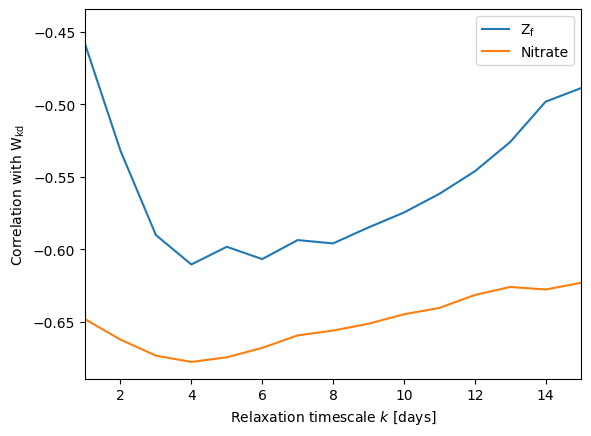

In [15]:
fig, ax = plt.subplots()
ax.plot(tdelay, wkd_correlation_zf, label=r"$\mathsf{Z_f}$")
ax.plot(tdelay, wkd_correlation_n, label="Nitrate")
ax.set_xlabel(r"Relaxation timescale $k$ [$\mathsf{days}$]")
ax.set_ylabel(r"Correlation with $\mathsf{W_{kd}}$")
ax.legend()
ax.set_xlim(1, 15)
ax.minorticks_off()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.477
Model:                            WLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     250.8
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           1.37e-40
Time:                        20:20:41   Log-Likelihood:                -1096.5
No. Observations:                 277   AIC:                             2197.
Df Residuals:                     275   BIC:                             2204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.5490      0.656    -23.713      0.000     -16.840     -14.258
x1          -299.3678     18.903    -15.837      0.000    -336.582    -262.154
==============================================================================
Omnibus:                       68.739   Durbin-Watson:                   1.370
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              159.535
Skew:                          -1.185   Prob(JB):                     2.28e-35
Kurtosis:                       5.864   Cond. No.                         36.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

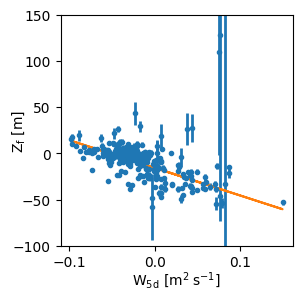

In [16]:
wind_use = "w5d"
wind_al_nhl, nhl_al_wind = xr.align(wind, nhl_grid)
m = dt2cal(nhl_al_wind["time"].values).T[1]
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use]))
wls_fit = sm.WLS(
    nhl_al_wind["Zf"][mask].values,
    sm.add_constant(wind_al_nhl[wind_use][mask].values),
    1 / (nhl_al_wind["Zf_err"][mask].values ** 2),
    missing="drop",
).fit()
fit = wls_fit.params[::-1]
r_squared = wls_fit.rsquared

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
ax.plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
ax.set_ylim(-100, 150)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{m^2 \\; s^{-1}}$]", labelpad=0)
ax.set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
bbox = dict(boxstyle="round", fc="w")
wls_fit.summary()

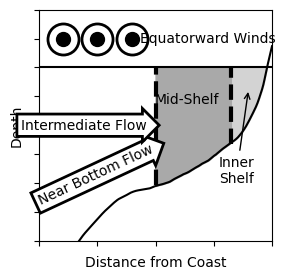

In [17]:
topo_smoothed = savgol_filter(topo, 100, 1)
plt.figure(figsize=(3, 3))
plt.plot(meters, topo_smoothed, "-", label="s=0", c="k")
plt.xlim(-40, 0)
plt.ylim(-120, 40)
plt.minorticks_off()
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])
bbox = dict(boxstyle="rarrow,pad=0.3", fc="w", ec="k", lw=2)
plt.annotate(
    "Near Bottom Flow",
    xy=(-20, -95),
    fontsize=10,
    bbox=bbox,
    color="k",
    rotation=25,
    ha="right",
)
plt.annotate(
    "Intermediate Flow",
    xy=(-21.5, -40),
    fontsize=10,
    bbox=bbox,
    color="k",
    rotation=0,
    ha="right",
    va="center",
)
plt.annotate(
    "Inner\nShelf",
    xy=(-4, -15),
    xytext=(-6, -80),
    fontsize=10,
    bbox=None,
    color="k",
    rotation=0,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="k"),
)
plt.annotate(
    "Mid-Shelf", xy=(-9, -25), fontsize=10, bbox=None, color="k", rotation=0, ha="right"
)
bbox = dict(boxstyle="larrow,pad=0.3", fc="w", ec="k", lw=2)
# plt.annotate(
#     'Ekman Transport',
#     xy=(-29.5, -12),
#     fontsize=10,
#     bbox=bbox,
#     color='k',
#     rotation=0,
#     ha='center',
# )
plt.axhline(0, color="k")
# plt.axhline(0, color='k')
# plt.axvline(-20, -color='k')
plt.fill_between(
    meters[(meters > -7) & (topo_smoothed < 0)],
    topo_smoothed[(meters > -7) & (topo_smoothed < 0)],
    0,
    color="lightgrey",
)
plt.fill_between(
    meters[(meters > -20) & (meters < -7) & (topo_smoothed < 0)],
    topo_smoothed[(meters > -20) & (meters < -7) & (topo_smoothed < 0)],
    0,
    color="darkgrey",
)
plt.xlabel("Distance from Coast")
plt.ylabel("Depth")
# plt.gca().set_aspect(1)
plt.scatter(
    [-24, -30, -36], [20, 20, 20], s=500, edgecolors="black", c="white", linewidths=2
)
plt.scatter([-24, -30, -36], [20, 20, 20], s=100, c="black")
plt.annotate(
    "Equatorward Winds",
    xy=(-11, 20),
    fontsize=10,
    color="k",
    rotation=0,
    ha="center",
    va="center",
)
plt.axvline(-7, 0.42, 0.75, c="k", ls="--", lw=3)
plt.axvline(-20, 0.24, 0.75, c="k", ls="--", lw=3)
# plt.scatter([-20], [20], s=[100])
# plt.savefig(
#     os.path.join(notebook_dir, "../manuscript/2d-upwelling-schematic.pdf"), format="pdf"
# )